# Module 9 — Medical Imaging Applications

This module synthesizes earlier modules into the plotting patterns that radiology figures need: `imshow()`, contours, colormaps, alpha overlays, and multi-panel layouts.

The examples use 2D NumPy arrays rather than real DICOM files. Once a CT or MR slice is loaded with tools such as pydicom or SimpleITK, matplotlib sees the pixel data as a 2D array anyway.

```text
┌───────────────────────────────────────────────────────────┐
│ In radiology figures, three layer types are stacked:      │
│                                                           │
│ 1. BASE IMAGE  — anatomy, usually grayscale CT/MR         │
│ 2. OVERLAY     — heatmap, mask, segmentation              │
│ 3. ANNOTATION  — ROI contour, arrow, label, scalebar      │
│                                                           │
│ Every figure is a recipe for combining these layers.      │
└───────────────────────────────────────────────────────────┘
```

Layer stack intuition:

```text
┌──────────────────────────┐
top → │ Annotations: ROI, arrow │ ax.annotate(), ax.contour()
├──────────────────────────┤
│ Overlay: heatmap, α=.5   │ ax.imshow(..., alpha=...)
├──────────────────────────┤
bot → │ Base: grayscale slice   │ ax.imshow(..., cmap="gray")
└──────────────────────────┘
```

Each `ax.imshow()` or `ax.contour()` call adds another layer on top of what is already drawn. Order matters.

## 1. Abstracting away DICOM: what a slice is

A DICOM CT/MR slice, once loaded, is a 2D NumPy array plus metadata such as pixel spacing, orientation, and windowing information. For matplotlib, the slice itself is just an array of shape `(H, W)`.

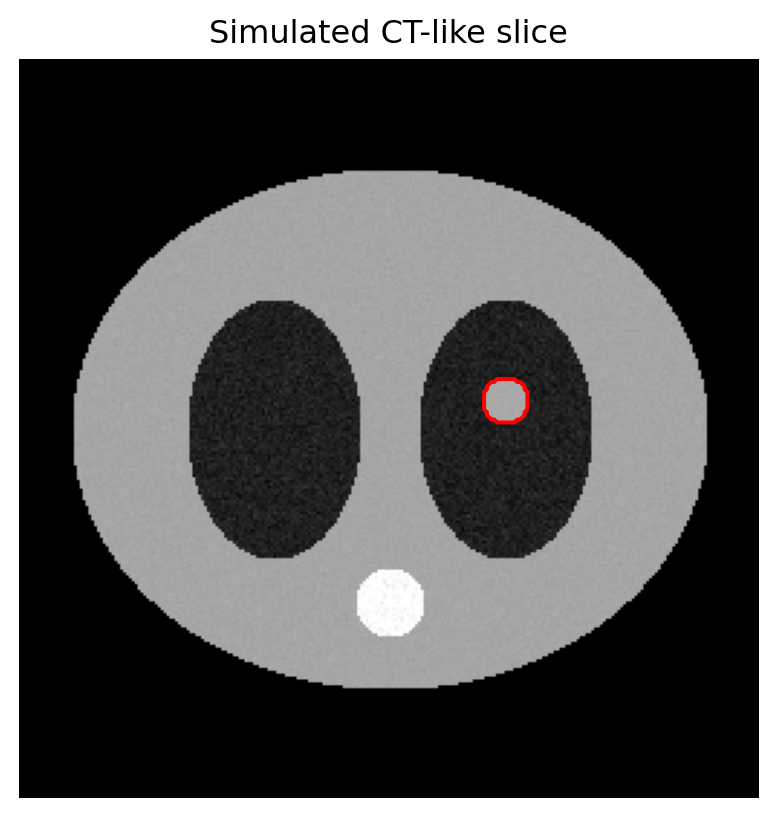

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def fake_ct_slice(size=256, seed=0):
    """Return a (size, size) array roughly mimicking a CT slice in HU."""
    rng = np.random.default_rng(seed)
    img = np.full((size, size), -1000.0)  # air background

    yy, xx = np.ogrid[:size, :size]

    # Body outline: large soft-tissue ellipse
    body = ((xx - size / 2) / 110) ** 2 + ((yy - size / 2) / 90) ** 2 < 1
    img[body] = 40 + rng.normal(0, 15, body.sum())

    # Lungs: two darker ellipses
    left_lung = ((xx - size / 2 + 40) / 30) ** 2 + ((yy - size / 2) / 45) ** 2 < 1
    right_lung = ((xx - size / 2 - 40) / 30) ** 2 + ((yy - size / 2) / 45) ** 2 < 1
    img[left_lung] = -800 + rng.normal(0, 50, left_lung.sum())
    img[right_lung] = -800 + rng.normal(0, 50, right_lung.sum())

    # Lesion in the right lung
    lesion = ((xx - size / 2 - 40) ** 2 + (yy - size / 2 + 10) ** 2) < 8 ** 2
    img[lesion] = 60 + rng.normal(0, 10, lesion.sum())

    # Spine: posterior midline bone
    spine = (xx - size / 2) ** 2 + (yy - size / 2 - 60) ** 2 < 12 ** 2
    img[spine] = 600 + rng.normal(0, 50, spine.sum())

    return img, lesion

img, lesion_mask = fake_ct_slice()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray", vmin=-1000, vmax=600)
ax.contour(lesion_mask, levels=[0.5], colors="red", linewidths=1.5)
ax.set_title("Simulated CT-like slice")
ax.axis("off")
plt.show()

Mock anatomy of the simulated slice:

```text
┌──────────────────────────────────────┐
│ air (-1000)                          │
│   ╭────────────────────────╮         │
│   │ soft tissue (~40 HU)   │         │
│   │   ◯ L lung   R lung ◯  │         │
│   │     (-800)   (-800)    │         │
│   │              ● lesion  │         │
│   │        ⬤ spine (~600)  │         │
│   ╰────────────────────────╯         │
└──────────────────────────────────────┘
```

For the rest of this module, treat `img` as a real CT slice and `lesion_mask` as a ground-truth segmentation.

## 2. Pattern 1: display a slice with proper windowing

The most basic radiology figure is a slice shown in a clinical window.

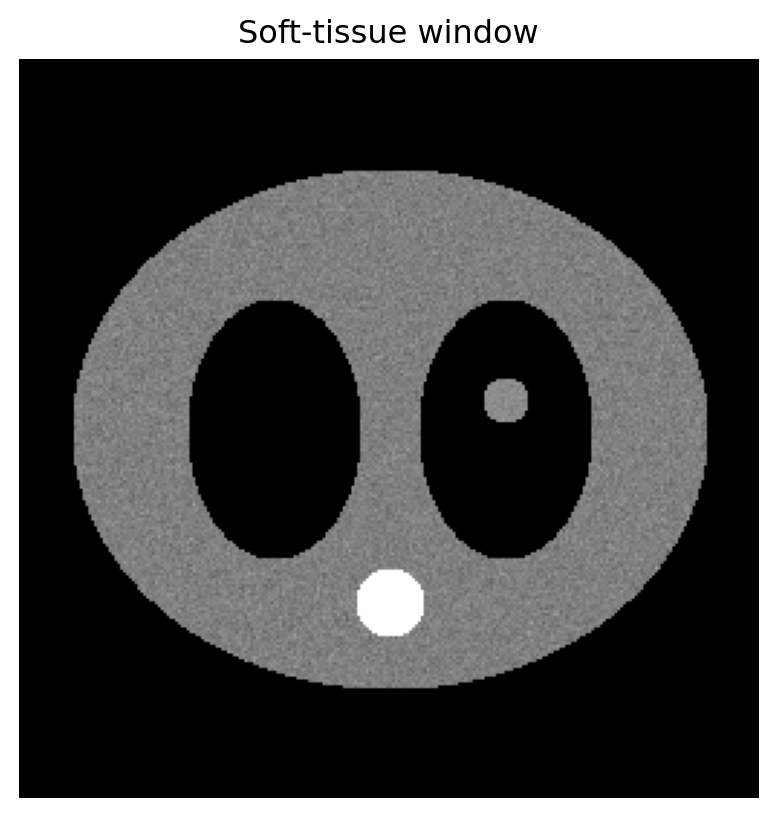

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)  # soft-tissue window
ax.set_title("Soft-tissue window")
ax.axis("off")
plt.show()

Non-negotiables for radiology display:

- Use `cmap="gray"` or sometimes `"bone"` for anatomical display.
- Set explicit `vmin` and `vmax`; auto-windowing makes each slice look different.
- Use `ax.axis("off")`; image axes rarely add meaning.
- Keep square aspect; `imshow()` preserves it by default.

Window/level conversion:

```text
vmin = level − width/2
vmax = level + width/2

Soft tissue  W=400,  L=40   → vmin=-160,  vmax=240
Lung         W=1500, L=-600 → vmin=-1350, vmax=150
Bone         W=2000, L=300  → vmin=-700,  vmax=1300
Brain        W=80,   L=40   → vmin=0,     vmax=80
Mediastinum  W=350,  L=50   → vmin=-125,  vmax=225
```

## 3. Pattern 2: multi-window comparison

A classic radiology figure shows the same slice in multiple windows.

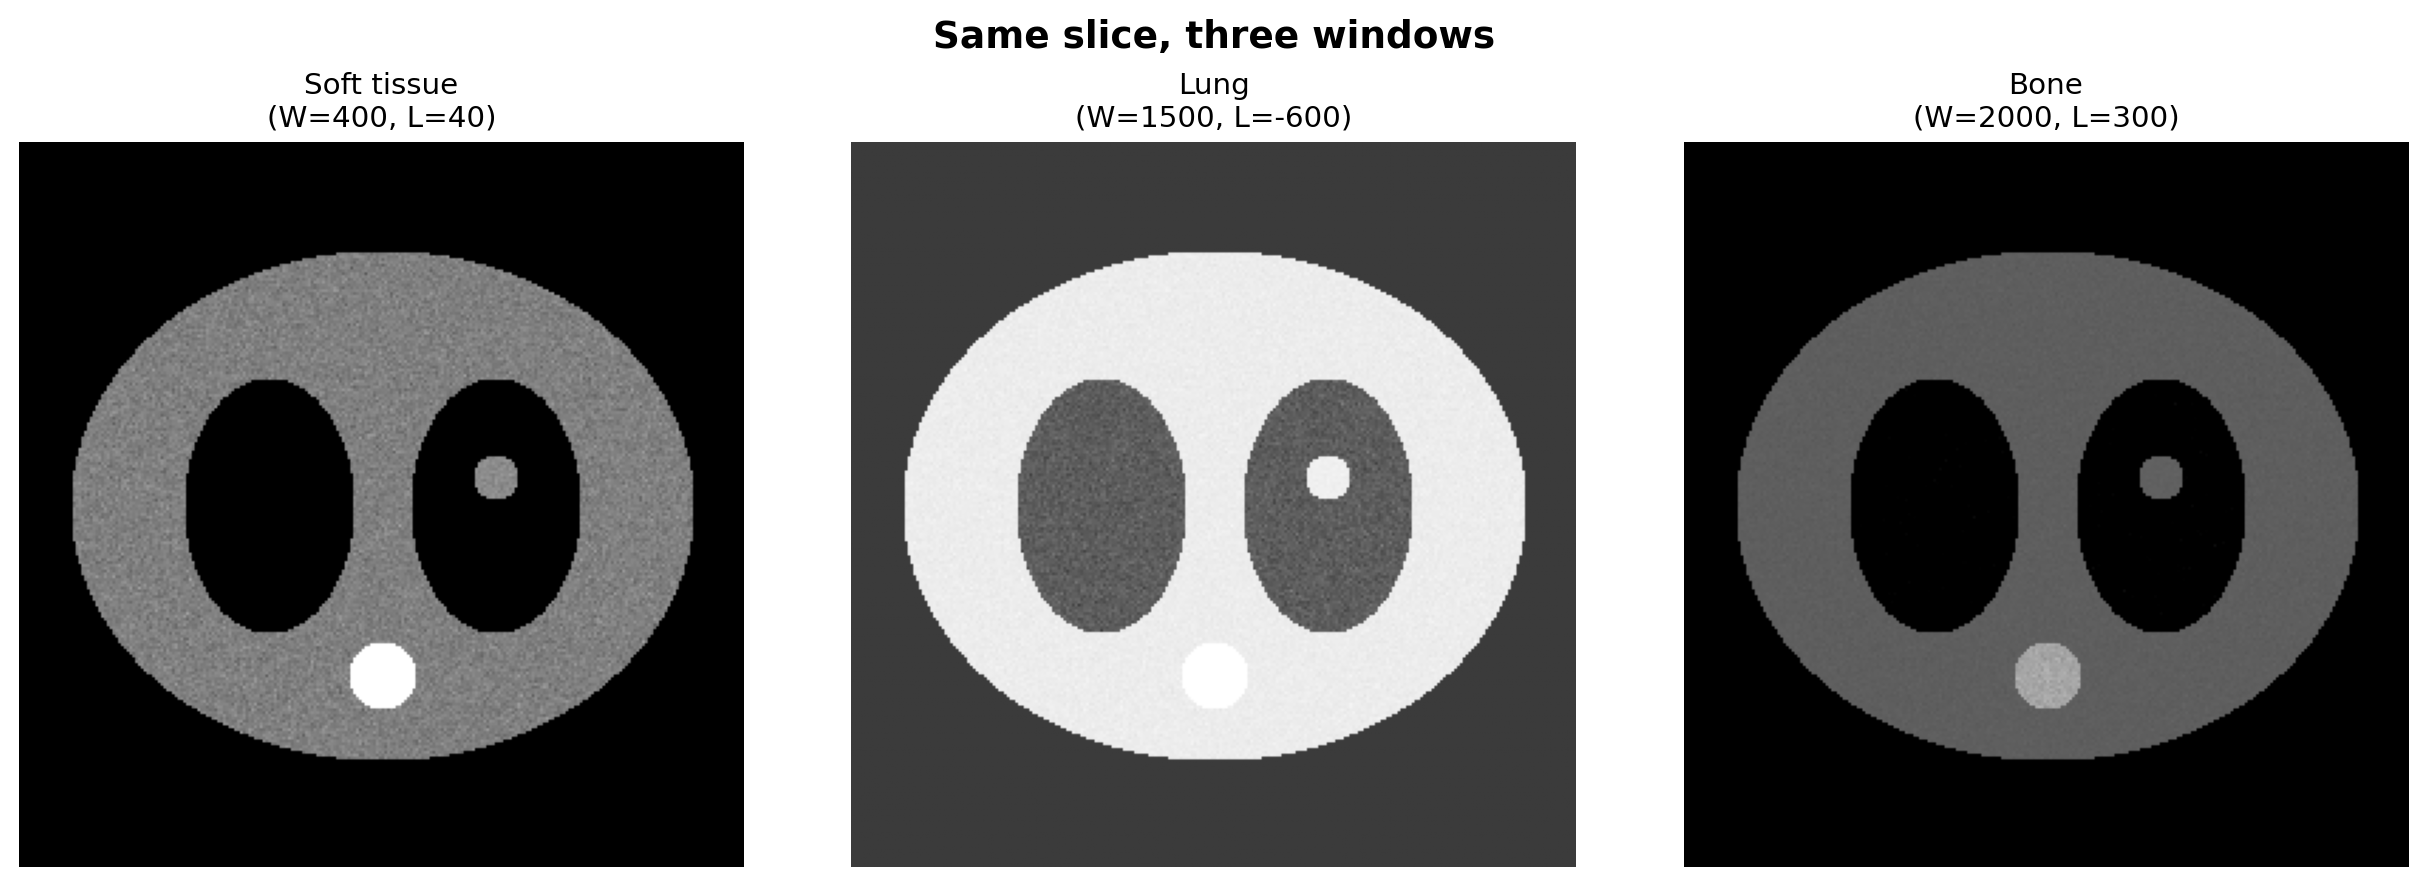

In [3]:
windows = [
    ("Soft tissue", -160, 240),
    ("Lung", -1350, 150),
    ("Bone", -700, 1300),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), layout="constrained")

for ax, (name, vmin, vmax) in zip(axes, windows):
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{name}\n(W={vmax - vmin}, L={(vmax + vmin) / 2:.0f})", fontsize=11)
    ax.axis("off")

fig.suptitle("Same slice, three windows", fontsize=14, fontweight="bold")
plt.show()

This is the medical imaging equivalent of a faceted comparison plot. The key is that the pixel data are the same while the displayed value range changes.

## 4. Pattern 3: heatmap overlay

For AI work, a common task is showing where the model is looking. The recipe:

1. draw the grayscale anatomy first
2. draw the heatmap on top with alpha
3. add a colorbar for the heatmap, not the grayscale image

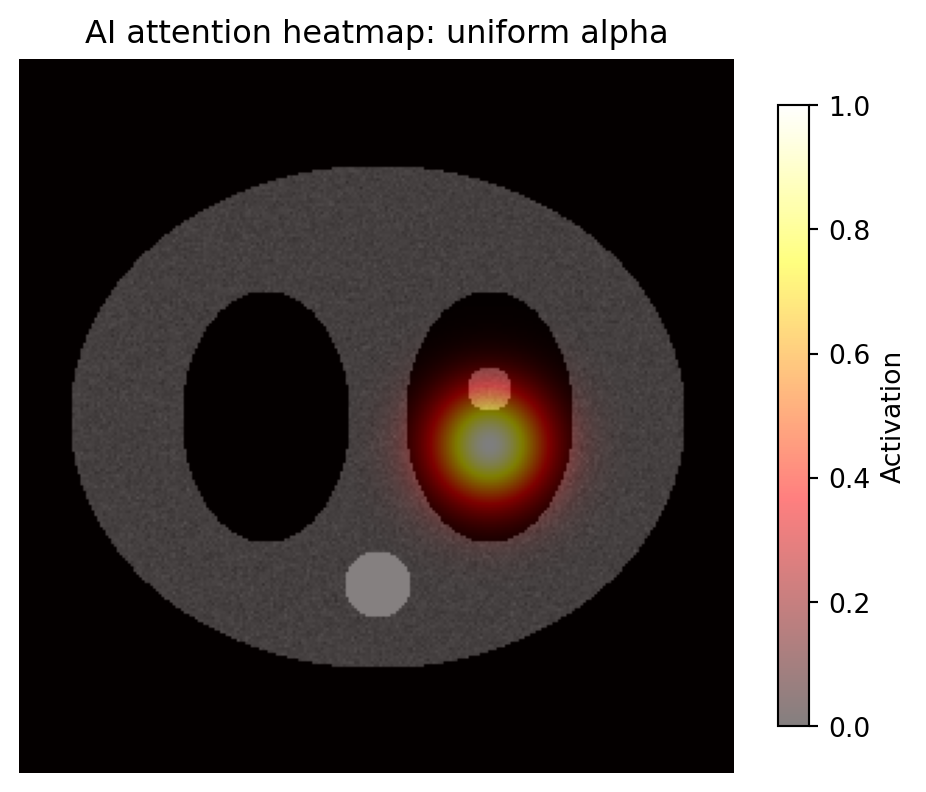

In [4]:
yy, xx = np.indices(img.shape)
heatmap = np.exp(-((xx - 168) ** 2 + (yy - 138) ** 2) / (2 * 15 ** 2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
hm = ax.imshow(heatmap, cmap="hot", alpha=0.5, vmin=0, vmax=1)
ax.set_title("AI attention heatmap: uniform alpha")
ax.axis("off")
fig.colorbar(hm, ax=ax, shrink=0.7, label="Activation")
plt.show()

A scalar `alpha=0.5` dims the whole heatmap, including pixels where activation is near zero. That can make the grayscale image look hazy everywhere.

A better pattern is an alpha array: transparent where activation is low, more opaque where activation is high.

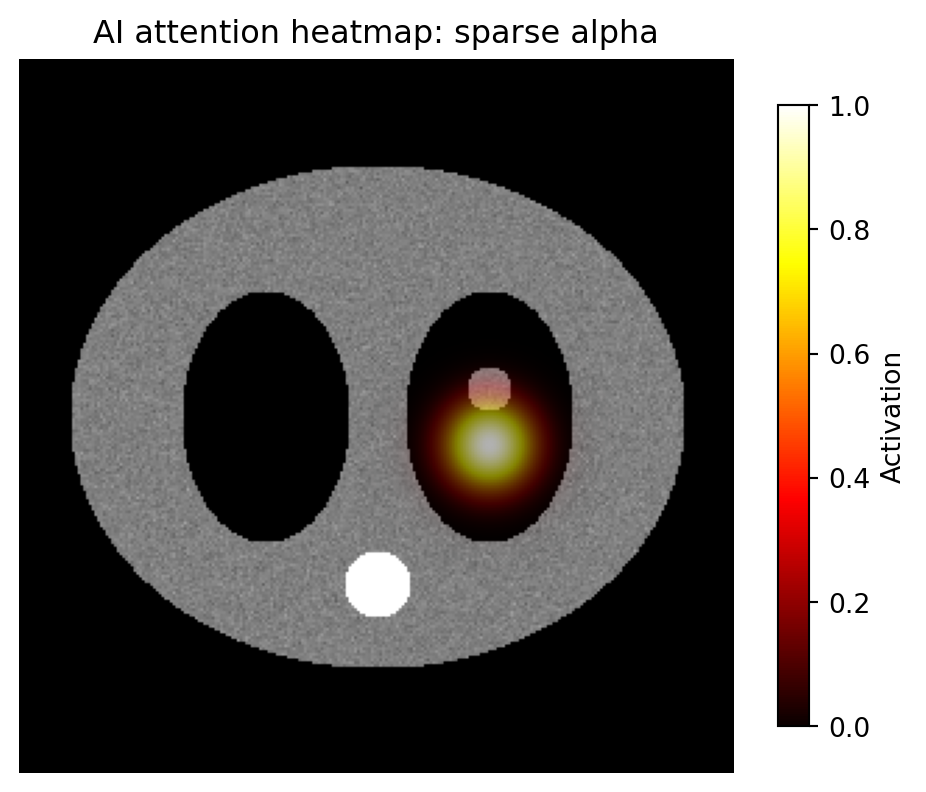

In [5]:
alpha_array = np.clip(heatmap * 0.7, 0, 0.7)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
hm = ax.imshow(heatmap, cmap="hot", alpha=alpha_array, vmin=0, vmax=1)
ax.set_title("AI attention heatmap: sparse alpha")
ax.axis("off")
fig.colorbar(hm, ax=ax, shrink=0.7, label="Activation")
plt.show()

```text
alpha=0.5 scalar              alpha=array
────────────────              ─────────────────────────
hot  ▓▓▓                       hot  ▓▓▓
warm ▒▒▒  all pixels 50%       warm ▒▒░  partially transparent
cool ░░░  transparent          cool      fully transparent
```

Sparse-alpha overlays are one of the most important techniques for clean AI/radiology figures.

## 5. Pattern 4: segmentation mask overlay

For a binary or label mask, use a colormap with a transparent background.

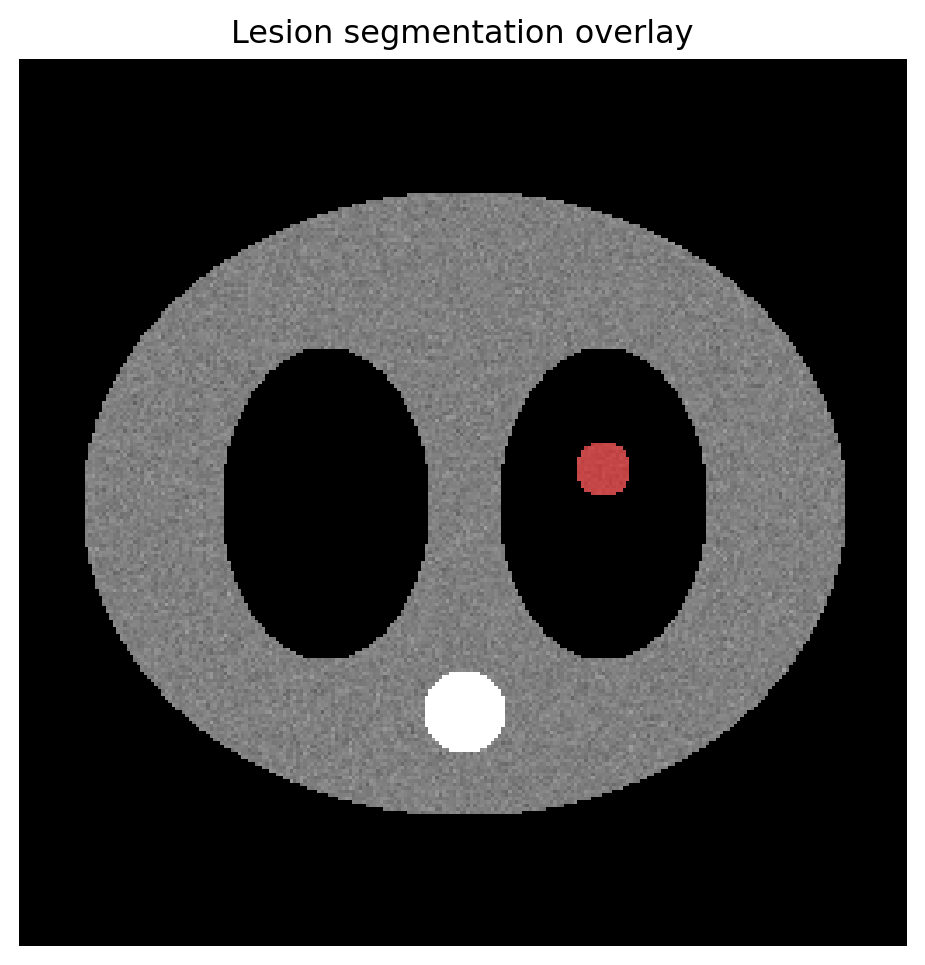

In [6]:
from matplotlib.colors import ListedColormap

mask_cmap = ListedColormap([
    (0, 0, 0, 0),    # label 0: transparent
    (1, 0, 0, 0.5),  # label 1: semi-transparent red
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
ax.imshow(lesion_mask.astype(int), cmap=mask_cmap, vmin=0, vmax=1)
ax.set_title("Lesion segmentation overlay")
ax.axis("off")
plt.show()

The trick is the custom `ListedColormap`: label 0 maps to fully transparent RGBA `(0, 0, 0, 0)`, so only the foreground appears.

For multi-class masks, extend the list:

```python
multi_cmap = ListedColormap([
    (0, 0, 0, 0),    # background
    (1, 0, 0, 0.5),  # liver / class 1
    (0, 1, 0, 0.5),  # spleen / class 2
    (0, 0, 1, 0.5),  # kidney / class 3
])
```

## 6. Pattern 5: contour outline of an ROI

Sometimes a filled overlay hides too much anatomy. A contour preserves the base image while showing the boundary.

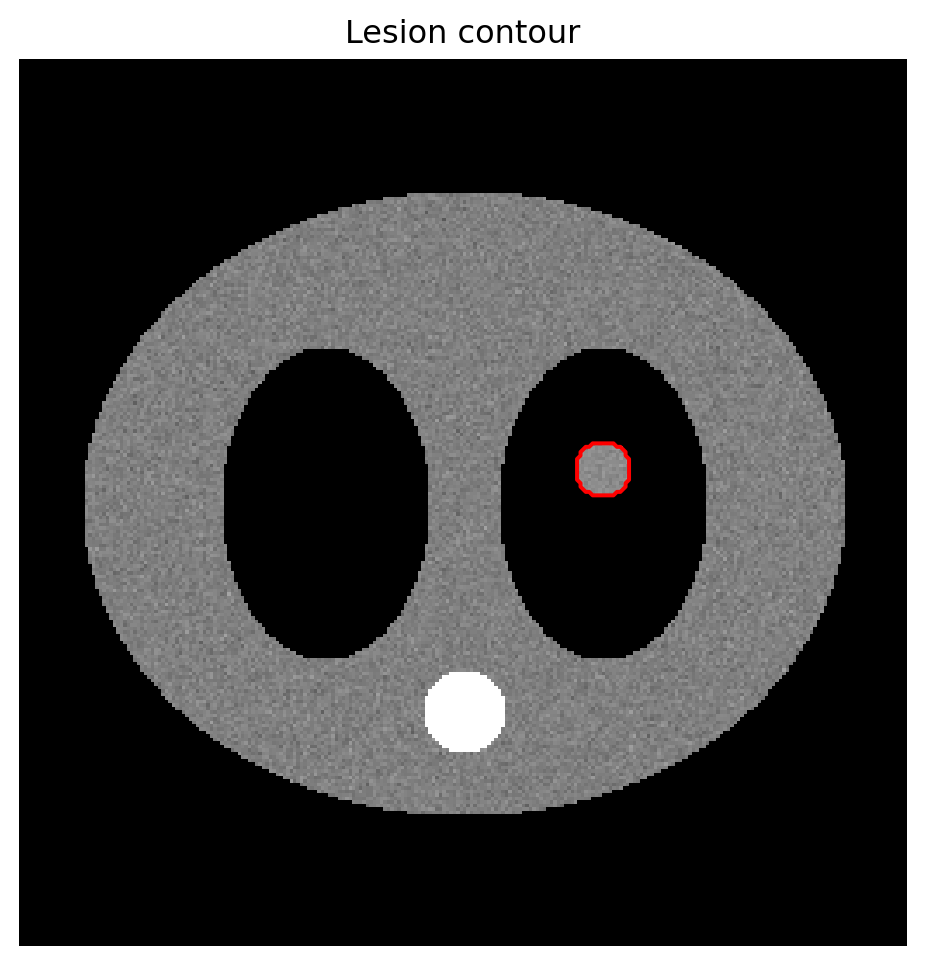

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
ax.contour(lesion_mask.astype(int), levels=[0.5], colors="red", linewidths=1.5)
ax.set_title("Lesion contour")
ax.axis("off")
plt.show()

`levels=[0.5]` finds the boundary where the mask transitions from 0 to 1.

```text
Filled overlay  → emphasize area or probability/density
Contour outline → preserve anatomy and show exact boundary
Both together   → common for agreement or multi-rater figures
```

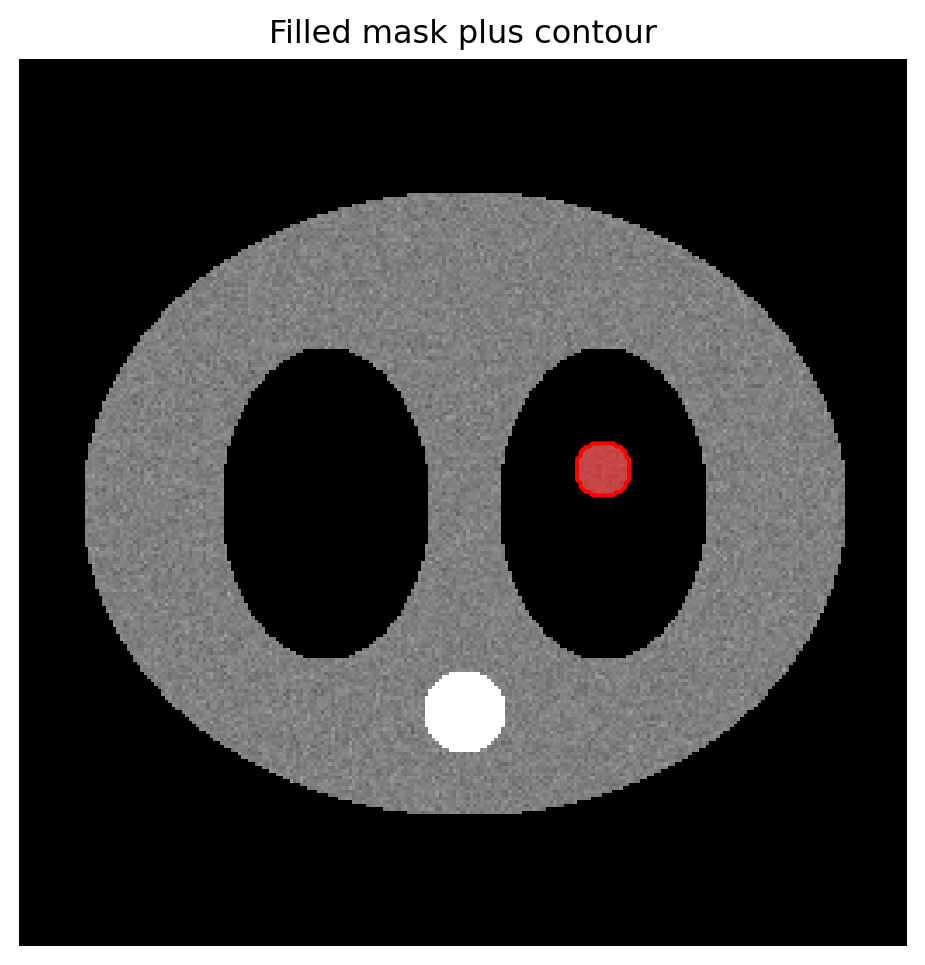

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
ax.imshow(lesion_mask.astype(int), cmap=mask_cmap, vmin=0, vmax=1)
ax.contour(lesion_mask, levels=[0.5], colors="red", linewidths=1.5)
ax.set_title("Filled mask plus contour")
ax.axis("off")
plt.show()

## 7. Pattern 6: ground truth vs prediction

This is a staple of AI papers: side-by-side panels with consistent windowing and overlay style.

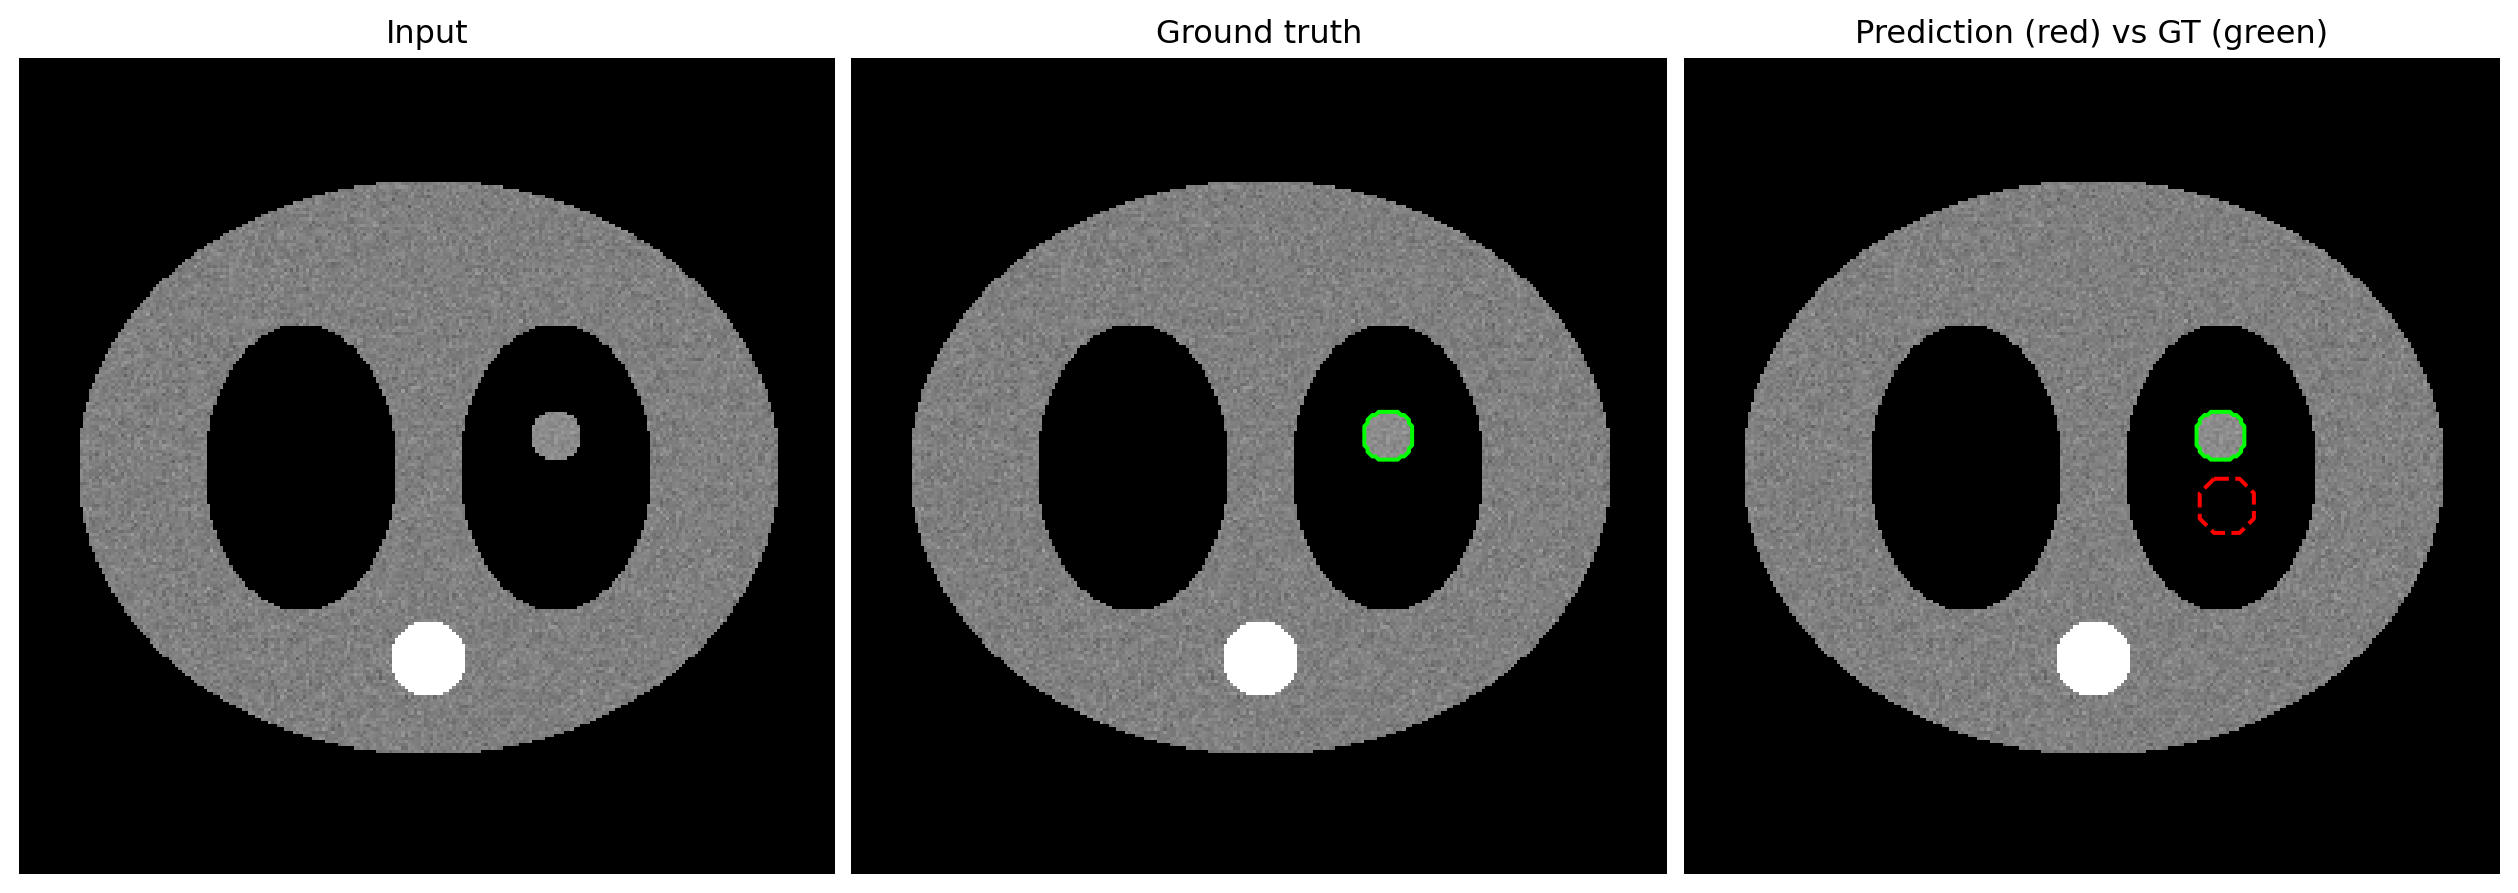

In [9]:
pred_mask = np.zeros_like(lesion_mask, dtype=bool)
pred_mask[((xx - 170) ** 2 + (yy - 140) ** 2) < 9 ** 2] = True

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), layout="constrained")

axes[0].imshow(img, cmap="gray", vmin=-160, vmax=240)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(img, cmap="gray", vmin=-160, vmax=240)
axes[1].contour(lesion_mask, levels=[0.5], colors="lime", linewidths=1.5)
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(img, cmap="gray", vmin=-160, vmax=240)
axes[2].contour(lesion_mask, levels=[0.5], colors="lime", linewidths=1.5)
axes[2].contour(pred_mask, levels=[0.5], colors="red", linewidths=1.5, linestyles="--")
axes[2].set_title("Prediction (red) vs GT (green)")
axes[2].axis("off")

plt.show()

Contours do not automatically produce a conventional legend. Use proxy lines.

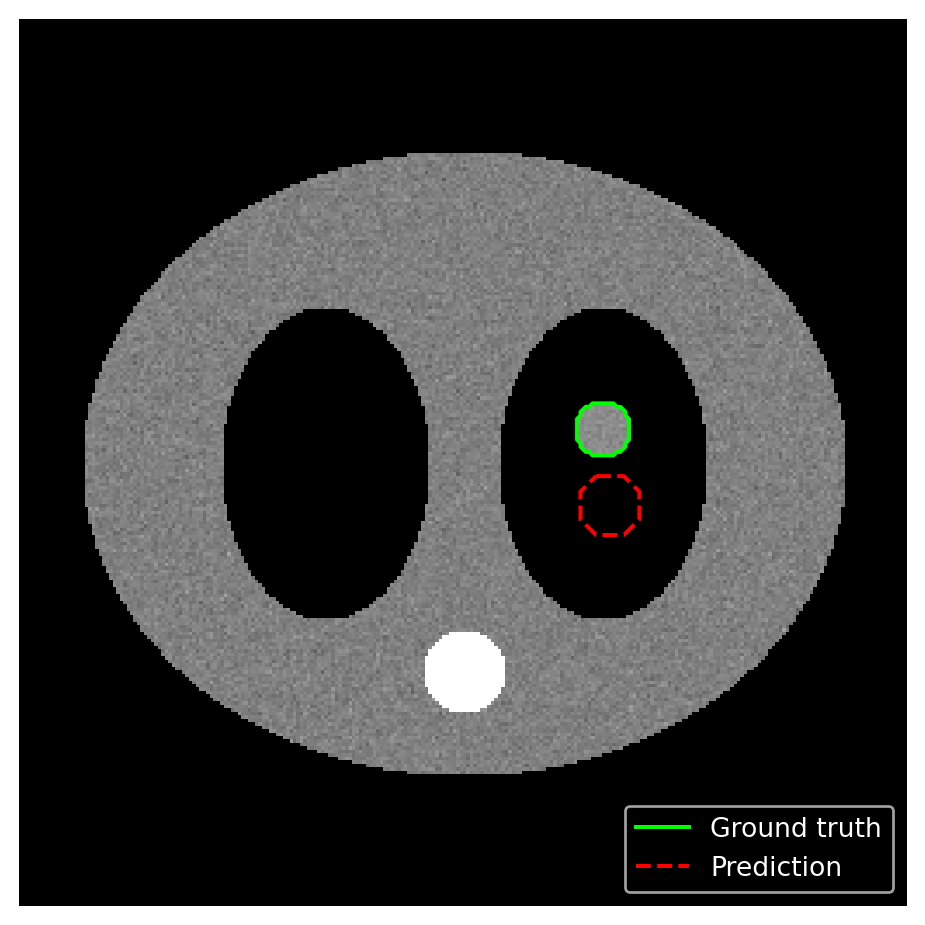

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
ax.contour(lesion_mask, levels=[0.5], colors="lime", linewidths=1.5)
ax.contour(pred_mask, levels=[0.5], colors="red", linewidths=1.5, linestyles="--")
ax.axis("off")

legend_elements = [
    Line2D([0], [0], color="lime", lw=1.5, label="Ground truth"),
    Line2D([0], [0], color="red", lw=1.5, ls="--", label="Prediction"),
]
ax.legend(handles=legend_elements, loc="lower right", facecolor="black", labelcolor="white")
plt.show()

## 8. Pattern 7: difference image

For per-pixel differences, such as post-pre contrast or prediction-ground truth probability, use a diverging colormap centered on zero.

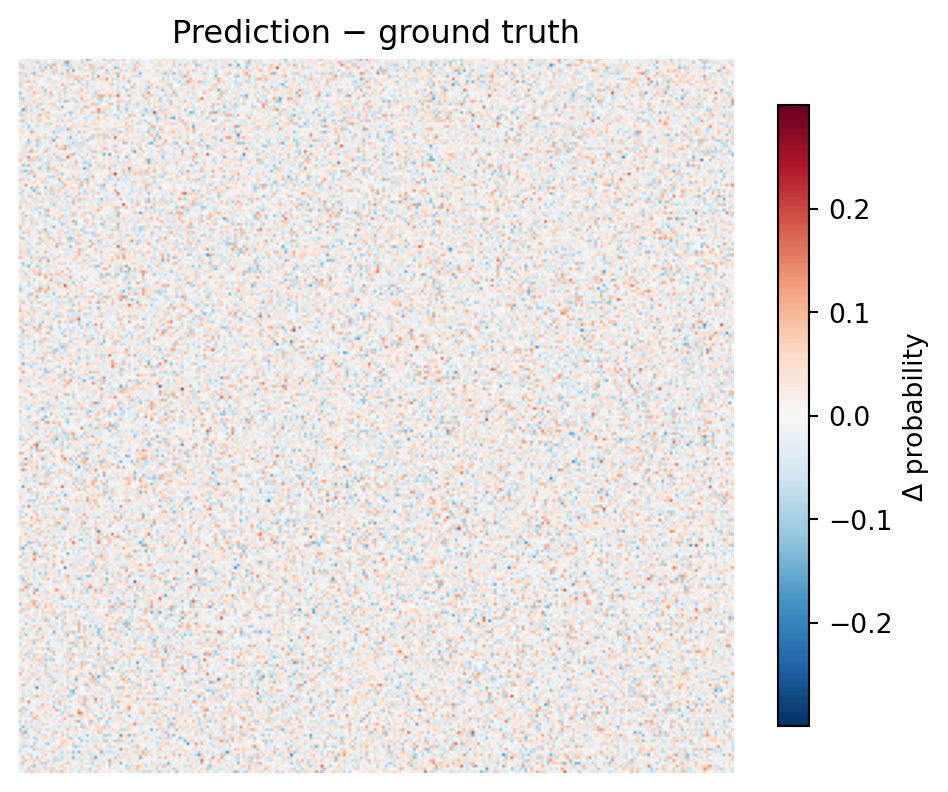

In [11]:
from matplotlib.colors import TwoSlopeNorm

rng = np.random.default_rng(1)
pred_prob = heatmap + rng.normal(0, 0.05, heatmap.shape)
gt_prob = heatmap
diff = pred_prob - gt_prob

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(diff, cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0, vmin=-0.3, vmax=0.3))
ax.set_title("Prediction − ground truth")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7, label="Δ probability")
plt.show()

`TwoSlopeNorm(vcenter=0)` ensures zero lands at the neutral midpoint of the colormap. Without it, zero can be shifted away from white and visually imply a difference where none exists.

## 9. Pattern 8: adding a scalebar

Radiology figures need physical scale. Pixel coordinates are not enough; millimeters matter.

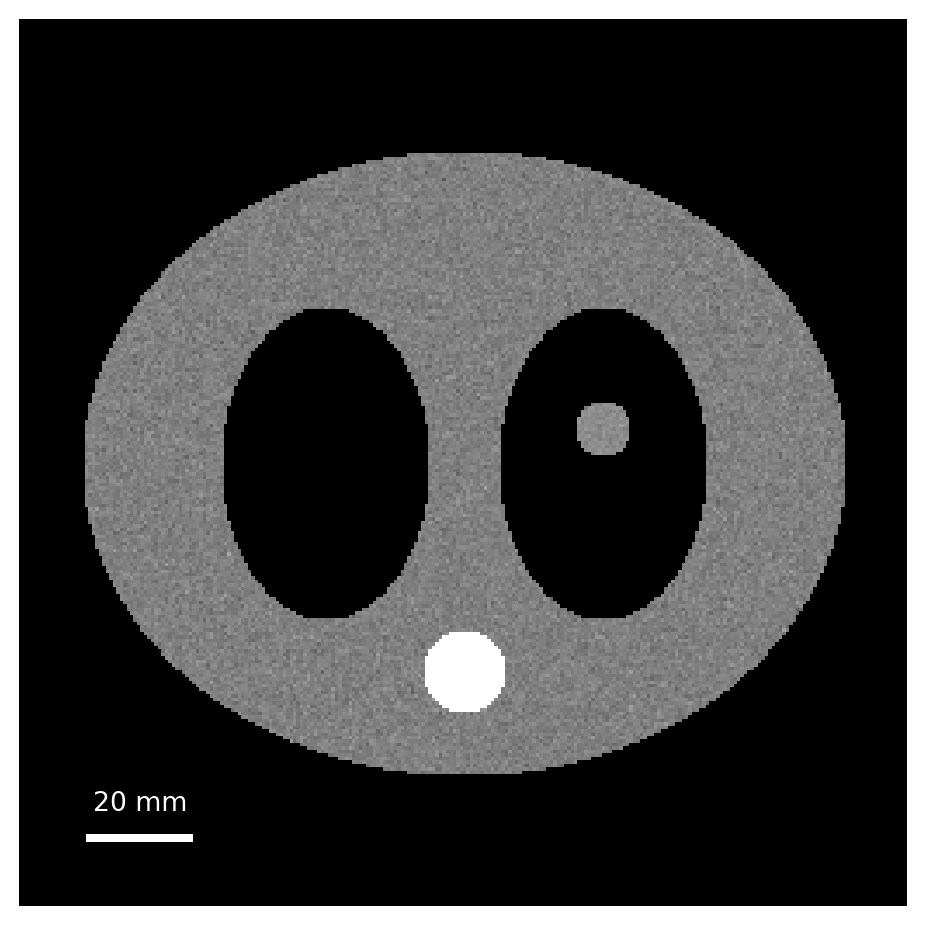

In [12]:
pixel_spacing_mm = 0.7  # from DICOM PixelSpacing in a real case

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
ax.axis("off")

bar_length_mm = 20
bar_length_px = bar_length_mm / pixel_spacing_mm
y0 = img.shape[0] - 20
x0 = 20

ax.plot([x0, x0 + bar_length_px], [y0, y0], color="white", linewidth=3)
ax.text(x0 + bar_length_px / 2, y0 - 8, f"{bar_length_mm} mm", color="white", ha="center", fontsize=10)
plt.show()

For polished scalebars with units and anchored placement, `matplotlib-scalebar` is worth installing, but a manual scalebar is often enough for controlled figures.

## 10. Pattern 9: intensity profile beside the image

The image plus line-profile figure is a clinical staple. Use a mosaic layout.

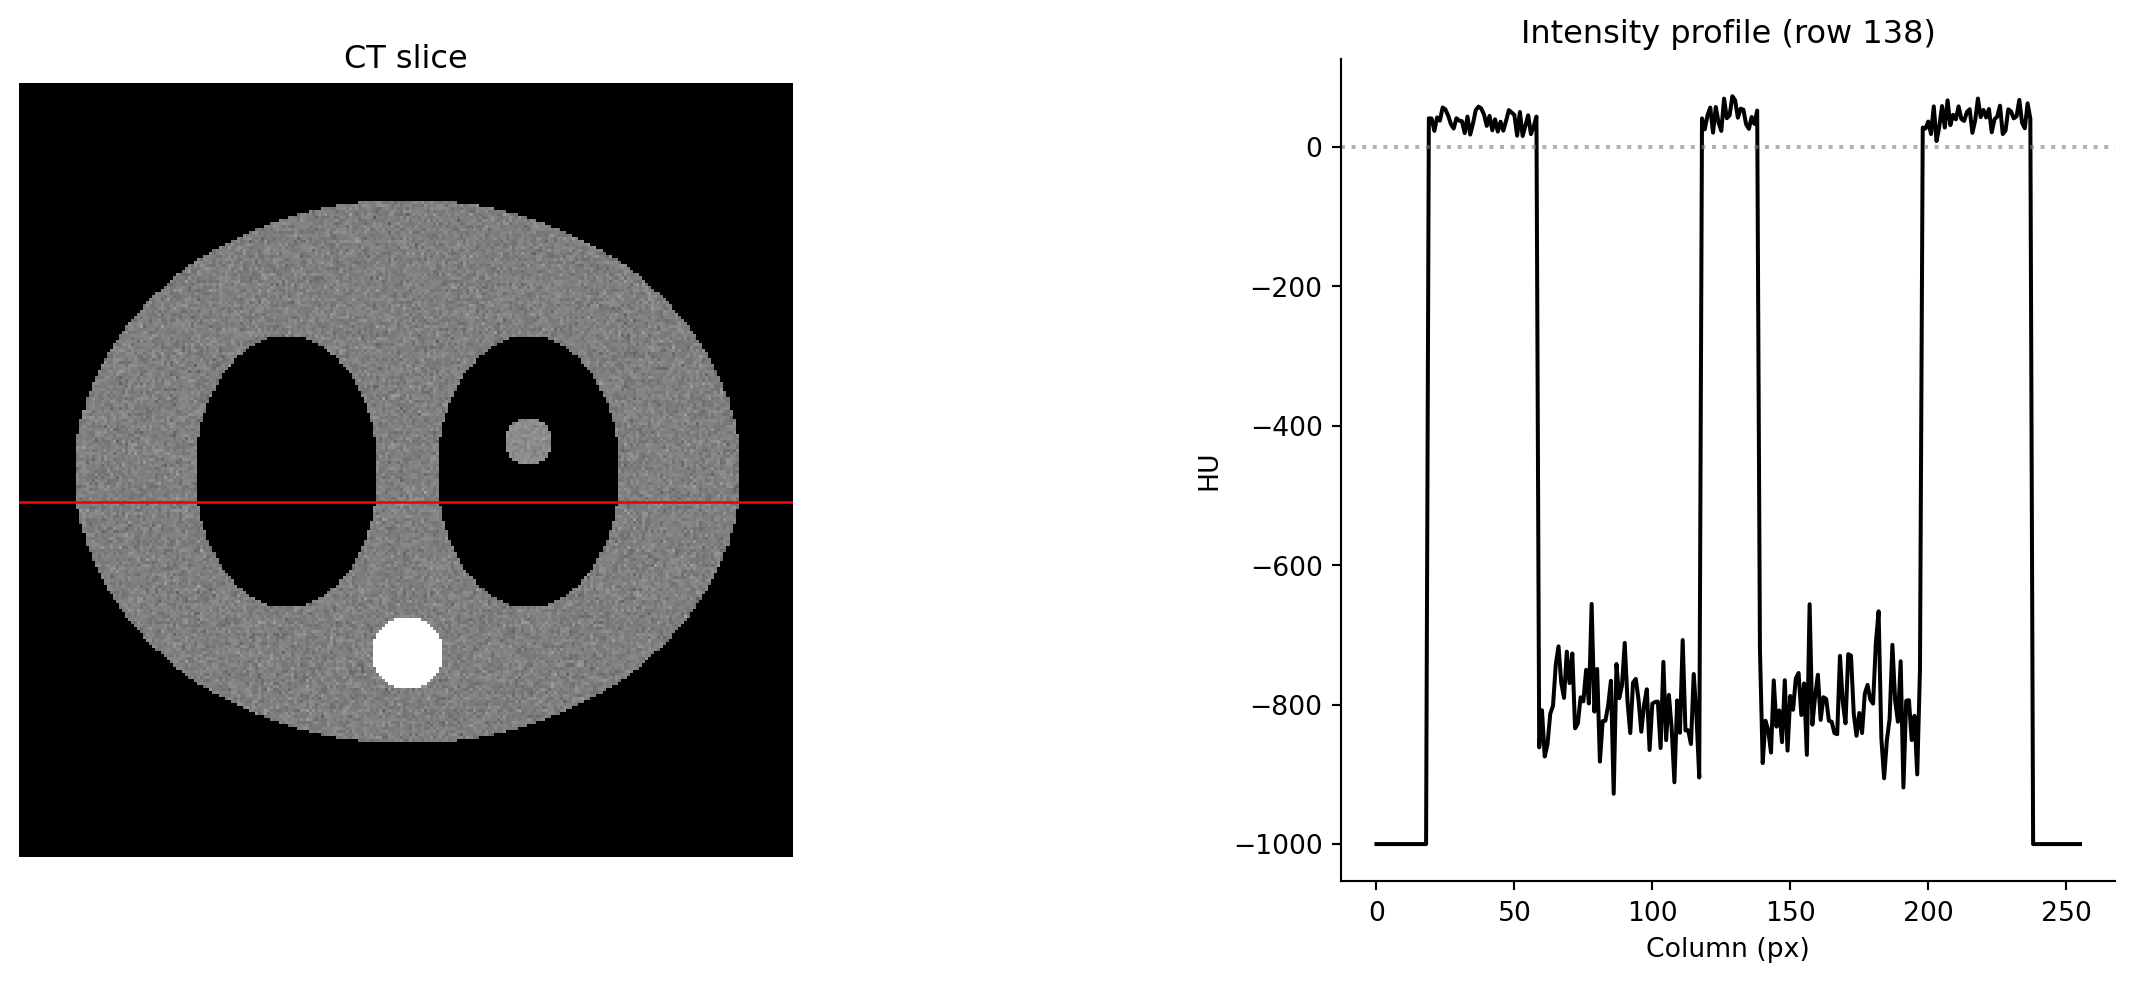

In [13]:
fig, axd = plt.subplot_mosaic(
    """
    II.PP
    II.PP
    II.PP
    """,
    figsize=(11, 5),
    layout="constrained",
)

axd["I"].imshow(img, cmap="gray", vmin=-160, vmax=240)
axd["I"].axhline(138, color="red", linewidth=1)
axd["I"].set_title("CT slice")
axd["I"].axis("off")

profile = img[138, :]
axd["P"].plot(profile, color="black")
axd["P"].axhline(0, color="gray", linestyle=":", alpha=0.6)
axd["P"].set_title("Intensity profile (row 138)")
axd["P"].set_xlabel("Column (px)")
axd["P"].set_ylabel("HU")
axd["P"].spines[["top", "right"]].set_visible(False)

plt.show()

`ax.axhline()` and `ax.axvline()` draw infinite-extent reference lines. They are useful for marking the profile location on the image.

## 11. Putting it together: a publication-style figure

This four-panel figure uses most of the patterns in the module.

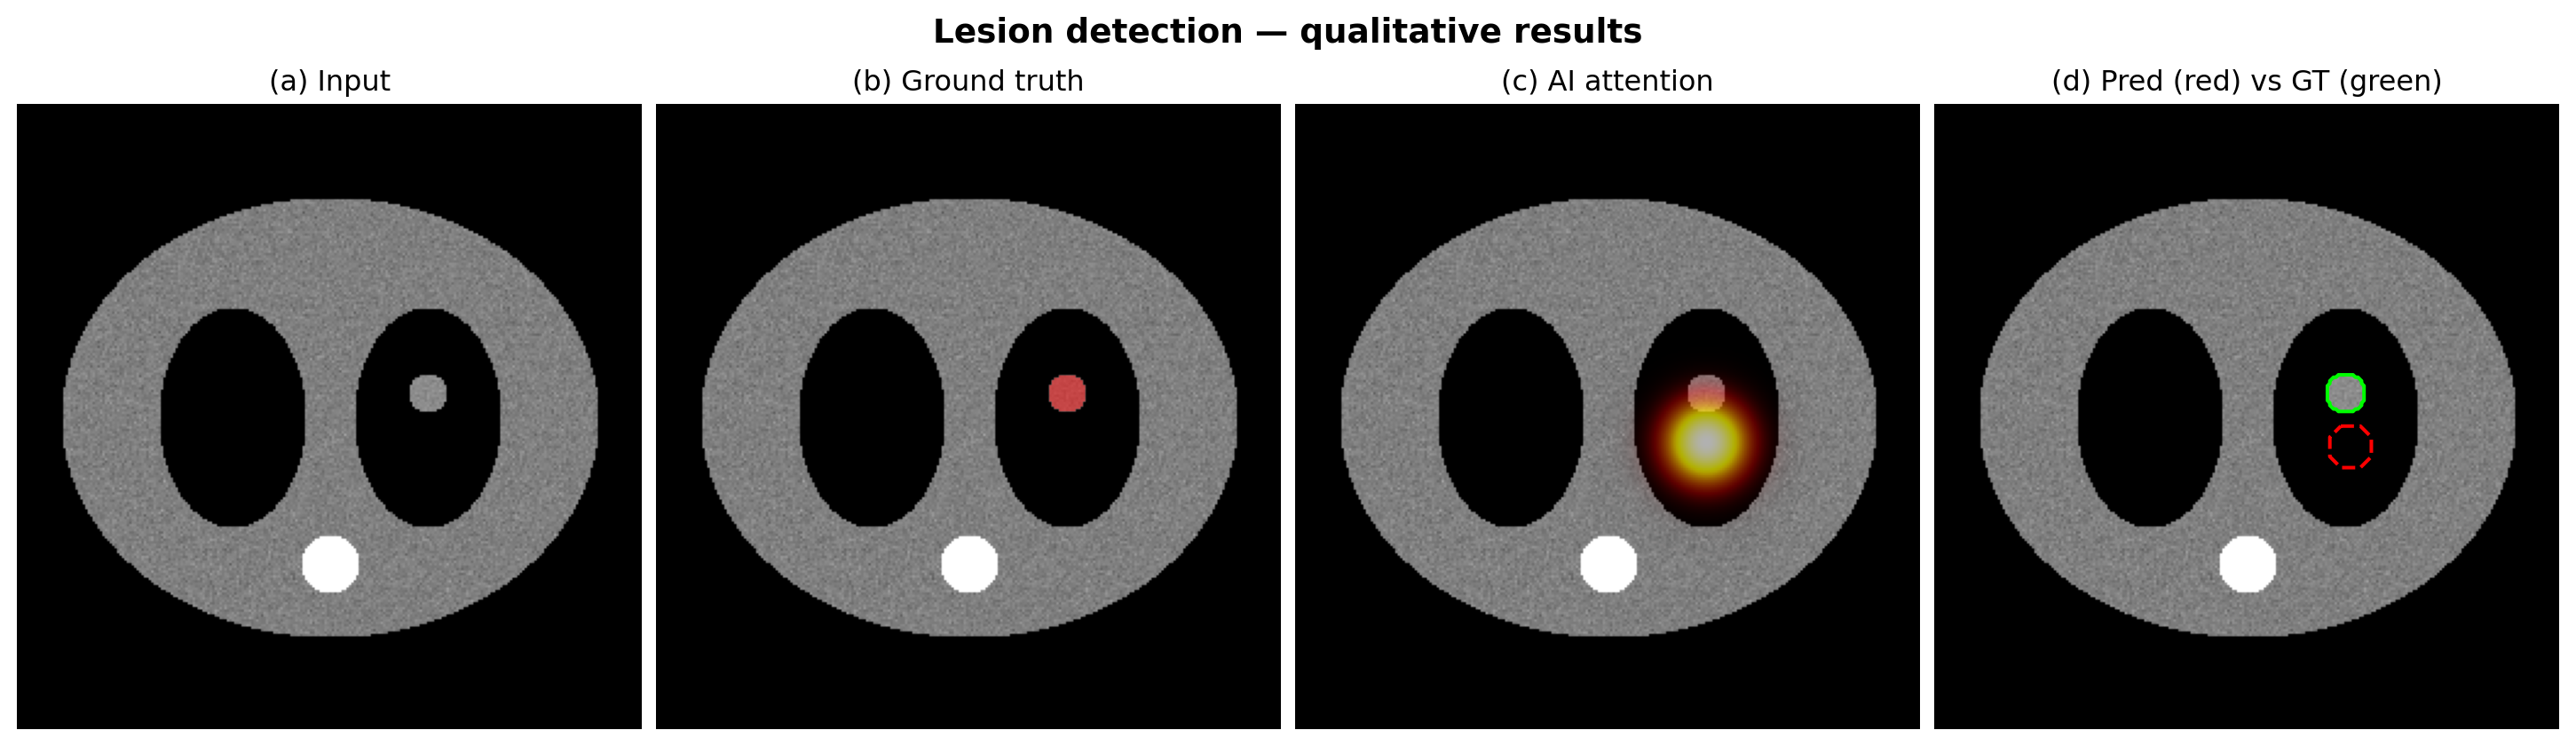

In [14]:
fig, axd = plt.subplot_mosaic(
    """
    ABCD
    """,
    figsize=(15, 4.5),
    layout="constrained",
)

# A: input image
axd["A"].imshow(img, cmap="gray", vmin=-160, vmax=240)
axd["A"].set_title("(a) Input")
axd["A"].axis("off")

# B: ground-truth segmentation as filled overlay
axd["B"].imshow(img, cmap="gray", vmin=-160, vmax=240)
axd["B"].imshow(lesion_mask.astype(int), cmap=mask_cmap, vmin=0, vmax=1)
axd["B"].set_title("(b) Ground truth")
axd["B"].axis("off")

# C: AI heatmap with sparse-alpha overlay
axd["C"].imshow(img, cmap="gray", vmin=-160, vmax=240)
hm = axd["C"].imshow(heatmap, cmap="hot", alpha=np.clip(heatmap, 0, 0.7), vmin=0, vmax=1)
axd["C"].set_title("(c) AI attention")
axd["C"].axis("off")

# D: prediction vs GT contours
axd["D"].imshow(img, cmap="gray", vmin=-160, vmax=240)
axd["D"].contour(lesion_mask, levels=[0.5], colors="lime", linewidths=1.5)
axd["D"].contour(pred_mask, levels=[0.5], colors="red", linewidths=1.5, linestyles="--")
axd["D"].set_title("(d) Pred (red) vs GT (green)")
axd["D"].axis("off")

fig.suptitle("Lesion detection — qualitative results", fontsize=14, fontweight="bold")
plt.show()

This is the basic shape of many radiology AI qualitative result figures: input, ground truth, heatmap, and prediction comparison.

## Summary cheat sheet

| Need | Tool |
|---|---|
| Display anatomy | `imshow(..., cmap="gray", vmin=, vmax=)` |
| Hide axes | `ax.axis("off")` |
| Heatmap overlay, uniform alpha | `imshow(..., cmap="hot", alpha=0.5)` |
| Heatmap overlay, sparse alpha | `imshow(..., alpha=clipped_array)` |
| Mask overlay with transparent background | `ListedColormap` with `(0,0,0,0)` for label 0 |
| ROI outline | `ax.contour(mask, levels=[0.5])` |
| Difference image | `cmap="RdBu_r"` + `TwoSlopeNorm(vcenter=0)` |
| Reference line on image | `ax.axhline()` / `ax.axvline()` |
| Multi-window panel | `subplots(1, n)` loop over `(vmin, vmax)` |
| Image plus side panel | `subplot_mosaic("II.P / II.P")` |
| Physical scale | manual scalebar or `matplotlib-scalebar` |

## Exercises

### Exercise 1: windowing

Generate `img, lesion_mask = fake_ct_slice()`. Build a 1×4 figure showing the same slice in lung, soft-tissue, bone, and brain windows. Title each panel with the window name and `(W, L)` values. Use `layout="constrained"`.

### Exercise 2: sparse-alpha heatmap

Generate the Gaussian heatmap from section 4. Make a 1×2 figure: left panel uses uniform `alpha=0.5`; right panel uses an alpha array equal to the heatmap itself. Compare how anatomy is preserved in low-activation regions.

### Exercise 3: multi-class mask

Build a fake 3-class label map: background `0`, lesion core `1` as an inner circle, and lesion edema `2` as a ring around it. Display it overlaid on the CT slice using `ListedColormap` with transparent background, semi-transparent red for label 1, and semi-transparent yellow for label 2. Add a manual legend.

### Exercise 4: GT vs prediction

Using `lesion_mask` as ground truth and a hand-crafted `pred_mask`, make a single panel showing both as contours: GT in green solid, prediction in red dashed. Add a proxy-line legend.

### Exercise 5: difference image

Compute `diff = pred_prob - gt_prob` from two slightly different Gaussian heatmaps. Display it with `cmap="RdBu_r"` and `TwoSlopeNorm(vcenter=0)`. Add a colorbar labeled `"Δ probability"`. Verify visually that zero is exactly white.

### Exercise 6: publication-quality dashboard

Reproduce the four-panel figure from section 11 while applying the `radai.mplstyle` from Module 7. Save it with:

```python
fig.savefig("lesion_detection.png", dpi=300, bbox_inches="tight")
```

This bridges directly into publication/export workflows.